In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

from src.preprocessing import fit_preprocessing, transform_preprocessor
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

In [48]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [49]:
# 데이터 호출
df = pd.read_csv("../01_data/processed/model_df.csv")

In [50]:
# 입력 변수(X)와 타겟 변수(y) 분리
X = df.drop('churned', axis=1)
y = df['churned']

In [51]:
# Train / Test / Validation 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [52]:
# 학습 데이터 기준 전처리 수행 및 검증/테스트 데이터 변환
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
X_test_prep = transform_preprocessor(X_test, encoders, scaler)

# XGB

In [53]:
# 탐색할 파라미터 후보 리스트 정의
n_estimators_list = [100, 200, 300]
learning_rate_list = [0.01, 0.05, 0.1]
max_depth_list = [3, 5, 7]
subsample_list = [0.8, 1.0]
colsample_bytree_list = [0.8, 1.0]

In [54]:
# HyperOpt용 탐색 공간 설정
search_space = {
    'n_estimators': hp.choice('n_estimators', n_estimators_list),
    'learning_rate': hp.choice('learning_rate', learning_rate_list),
    'max_depth': hp.choice('max_depth', max_depth_list),
    'subsample': hp.choice('subsample', subsample_list),
    'colsample_bytree': hp.choice('colsample_bytree', colsample_bytree_list)
}

In [55]:
# 튜닝용 목적함수 정의
def objective(params):
    model = XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
        **params
    )
    # 학습 데이터(X_tr_prep)로 학습
    model.fit(X_tr_prep, y_tr)
    # 검증 데이터(X_val_prep)로 성능 확인
    y_val_pred = model.predict(X_val_prep)
    score = f1_score(y_val, y_val_pred, average='macro')
    return {'loss': -score, 'status': STATUS_OK}

In [56]:
# 최적화 실행
trials = Trials()
best_idx = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    trials=trials,
    max_evals=50,  # 50번의 똑똑한 시도
    rstate=np.random.default_rng(seed=42)
)

100%|██████████| 50/50 [01:15<00:00,  1.52s/trial, best loss: -0.8425826784444178]


In [57]:
# 찾은 인덱스를 실제 파라미터 값으로 변환
best_params = {
    'n_estimators': n_estimators_list[best_idx['n_estimators']],
    'learning_rate': learning_rate_list[best_idx['learning_rate']],
    'max_depth': max_depth_list[best_idx['max_depth']],
    'subsample': subsample_list[best_idx['subsample']],
    'colsample_bytree': colsample_bytree_list[best_idx['colsample_bytree']]
}

In [58]:
# 최적의 파라미터로 최종 모델 학습
final_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    **best_params
)
final_xgb.fit(X_tr_prep, y_tr)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [59]:
# 최종 테스트 데이터(X_test_prep)로 결과 도출
y_test_pred = final_xgb.predict(X_test_prep)


HyperOpt가 찾은 최적 파라미터: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}

[최종 분류 보고서]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     12165
           1       0.85      0.85      0.85     12835

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



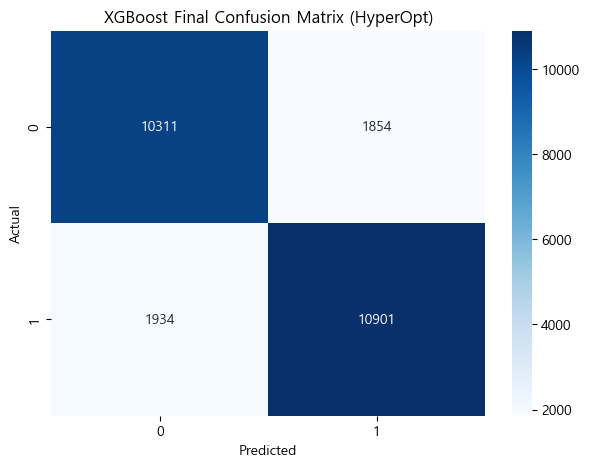

최종 Accuracy: 0.8485
최종 F1-Score: 0.8484


In [60]:
# XGBoost 최종 성능 출력 및 혼동행렬 시각화
print("\n" + "="*50)
print(f"HyperOpt가 찾은 최적 파라미터: {best_params}")
print("="*50)

print("\n[최종 분류 보고서]")
print(classification_report(y_test, y_test_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Final Confusion Matrix (HyperOpt)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"최종 Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"최종 F1-Score: {f1_score(y_test, y_test_pred, average='macro'):.4f}")

# LGBM

In [61]:
# LightGBM 탐색 파라미터 후보 정의

n_estimators_list_lgbm = [300, 500, 700, 1000]
learning_rate_list_lgbm = [0.01, 0.03, 0.05, 0.1]
max_depth_list_lgbm = [3, 5, 7, -1]
num_leaves_list_lgbm = [15, 31, 63, 127]
subsample_list_lgbm = [0.8, 1.0]
colsample_bytree_list_lgbm = [0.8, 1.0]

In [62]:
# HyperOpt용 LightGBM 탐색 공간 설정

search_space_lgbm = {
    'n_estimators': hp.choice('lgbm_n_estimators', n_estimators_list_lgbm),
    'learning_rate': hp.choice('lgbm_learning_rate', learning_rate_list_lgbm),
    'max_depth': hp.choice('lgbm_max_depth', max_depth_list_lgbm),
    'num_leaves': hp.choice('lgbm_num_leaves', num_leaves_list_lgbm),
    'subsample': hp.choice('lgbm_subsample', subsample_list_lgbm),
    'colsample_bytree': hp.choice('lgbm_colsample_bytree', colsample_bytree_list_lgbm)
}

In [63]:
# LightGBM 튜닝용 목적 함수 정의
def objective_lgbm(params):

    model = LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1,
        **params
    )

    model.fit(X_tr_prep, y_tr)

    y_pred = model.predict(X_val_prep)

    score = f1_score(y_val, y_pred, average='macro')

    return {
        'loss': -score,
        'status': STATUS_OK
    }

In [64]:
# HyperOpt로 LightGBM 최적 파라미터 탐색
trials_lgbm = Trials()

best_idx_lgbm = fmin(
    fn=objective_lgbm,
    space=search_space_lgbm,
    algo=tpe.suggest,
    trials=trials_lgbm,
    max_evals=50,
    rstate=np.random.default_rng(seed=42)
)

100%|██████████| 50/50 [03:26<00:00,  4.14s/trial, best loss: -0.8432825233314519]


In [65]:
# 탐색 결과를 실제 LightGBM 파라미터 값으로 변환
best_params_lgbm = {
    'n_estimators': n_estimators_list_lgbm[best_idx_lgbm['lgbm_n_estimators']],
    'learning_rate': learning_rate_list_lgbm[best_idx_lgbm['lgbm_learning_rate']],
    'max_depth': max_depth_list_lgbm[best_idx_lgbm['lgbm_max_depth']],
    'num_leaves': num_leaves_list_lgbm[best_idx_lgbm['lgbm_num_leaves']],
    'subsample': subsample_list_lgbm[best_idx_lgbm['lgbm_subsample']],
    'colsample_bytree': colsample_bytree_list_lgbm[best_idx_lgbm['lgbm_colsample_bytree']]
}

In [66]:
# 최적 파라미터로 LightGBM 최종 모델 학습
final_lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
    n_jobs=-1,
    **best_params_lgbm
)

final_lgbm.fit(X_tr_prep, y_tr)

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,3
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [67]:
# LightGBM 테스트 데이터 예측 수행
y_test_pred_lgbm = final_lgbm.predict(X_test_prep)


HyperOpt가 찾은 최적 파라미터: {'n_estimators': 1000, 'learning_rate': 0.05, 'max_depth': 3, 'num_leaves': 63, 'subsample': 1.0, 'colsample_bytree': 1.0}

[최종 분류 보고서]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     12165
           1       0.86      0.84      0.85     12835

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



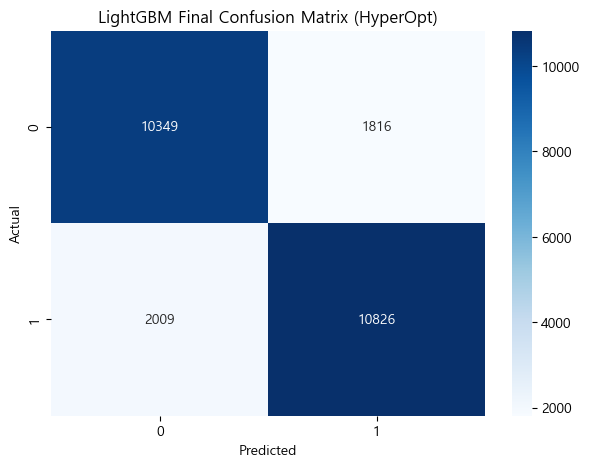

최종 Accuracy: 0.8470
최종 F1-Score: 0.8469


In [69]:
# LightGBM 최종 성능 출력 및 혼동행렬 시각화
print("\n" + "="*50)
print(f"HyperOpt가 찾은 최적 파라미터: {best_params_lgbm}")
print("="*50)

print("\n[최종 분류 보고서]")
print(classification_report(y_test, y_test_pred_lgbm))

# 혼동 행렬 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_lgbm), annot=True, fmt='d', cmap='Blues')
plt.title('LightGBM Final Confusion Matrix (HyperOpt)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"최종 Accuracy: {accuracy_score(y_test, y_test_pred_lgbm):.4f}")
print(f"최종 F1-Score: {f1_score(y_test, y_test_pred_lgbm, average='macro'):.4f}")

# catboost

In [70]:
from catboost import CatBoostClassifier

In [71]:
# CatBoost 탐색 파라미터 후보 정의

iterations_list_cat = [300, 500, 700, 1000]
learning_rate_list_cat = [0.01, 0.03, 0.05, 0.1]
depth_list_cat = [4, 6, 8, 10]
l2_leaf_reg_list_cat = [1, 3, 5, 7, 9]

In [72]:
# HyperOpt용 CatBoost 탐색 공간 설정

search_space_cat = {
    'iterations': hp.choice('cat_iterations', iterations_list_cat),
    'learning_rate': hp.choice('cat_learning_rate', learning_rate_list_cat),
    'depth': hp.choice('cat_depth', depth_list_cat),
    'l2_leaf_reg': hp.choice('cat_l2_leaf_reg', l2_leaf_reg_list_cat)
}

In [73]:
# CatBoost 튜닝용 목적 함수 정의
def objective_cat(params):

    model = CatBoostClassifier(
        random_state=42,
        verbose=0,
        **params
    )

    model.fit(X_tr_prep, y_tr)

    y_pred = model.predict(X_val_prep)

    score = f1_score(y_val, y_pred, average='macro')

    return {
        'loss': -score,
        'status': STATUS_OK
    }

In [74]:
# HyperOpt로 CatBoost 최적 파라미터 탐색
# 25분
trials_cat = Trials()

best_idx_cat = fmin(
    fn=objective_cat,
    space=search_space_cat,
    algo=tpe.suggest,
    trials=trials_cat,
    max_evals=50,
    rstate=np.random.default_rng(seed=42)
)

100%|██████████| 50/50 [26:03<00:00, 31.26s/trial, best loss: -0.843529010676854]


In [75]:
# 탐색 결과를 실제 CatBoost 파라미터 값으로 변환
best_params_cat = {
    'iterations': iterations_list_cat[best_idx_cat['cat_iterations']],
    'learning_rate': learning_rate_list_cat[best_idx_cat['cat_learning_rate']],
    'depth': depth_list_cat[best_idx_cat['cat_depth']],
    'l2_leaf_reg': l2_leaf_reg_list_cat[best_idx_cat['cat_l2_leaf_reg']]
}

best_params_cat

{'iterations': 1000, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 1}

In [76]:
# 최적 파라미터로 CatBoost 최종 모델 학습
final_cat = CatBoostClassifier(
    random_state=42,
    verbose=0,
    **best_params_cat
)

final_cat.fit(X_tr_prep, y_tr)

CatBoostClassifier(depth=10, iterations=1000, l2_leaf_reg=1, learning_rate=0.03, random_state=42, verbose=0)

In [77]:
# CatBoost 테스트 데이터 예측 및 확률값 계산
y_test_pred_cat = final_cat.predict(X_test_prep)
y_test_proba_cat = final_cat.predict_proba(X_test_prep)[:, 1]


HyperOpt가 찾은 최적 파라미터: {'iterations': 1000, 'learning_rate': 0.03, 'depth': 10, 'l2_leaf_reg': 1}

[최종 분류 보고서]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84     12165
           1       0.86      0.85      0.85     12835

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



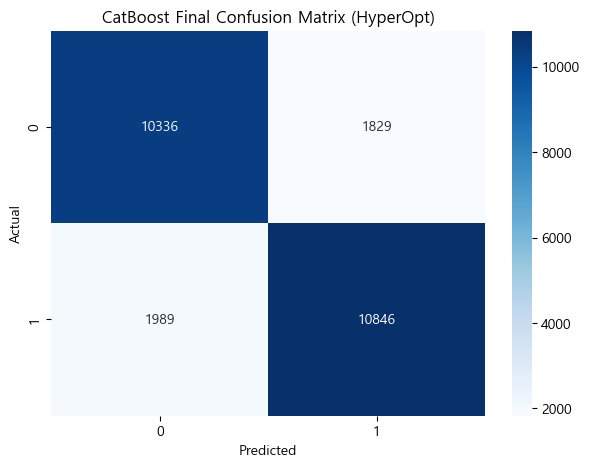

최종 Accuracy: 0.8473
최종 F1-Score: 0.8472


In [78]:
# CatBoost 최종 성능 출력 및 혼동행렬 시각화
print("\n" + "="*50)
print(f"HyperOpt가 찾은 최적 파라미터: {best_params_cat}")
print("="*50)

print("\n[최종 분류 보고서]")
print(classification_report(y_test, y_test_pred_cat))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_cat), annot=True, fmt='d', cmap='Blues')
plt.title('CatBoost Final Confusion Matrix (HyperOpt)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"최종 Accuracy: {accuracy_score(y_test, y_test_pred_cat):.4f}")
print(f"최종 F1-Score: {f1_score(y_test, y_test_pred_cat, average='macro'):.4f}")

# 비교

In [79]:
# 각 모델의 테스트 데이터 확률값 예측

y_test_proba_xgb = final_xgb.predict_proba(X_test_prep)[:, 1]
y_test_proba_lgbm = final_lgbm.predict_proba(X_test_prep)[:, 1]
y_test_proba_cat = final_cat.predict_proba(X_test_prep)[:,1]

In [85]:
# Accuracy / F1 / ROC-AUC 비교표 생성
compare_df = pd.DataFrame({
    'model': ['XGB', 'LGBM', 'CatBoost'],
    'accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_lgbm),
        accuracy_score(y_test, y_test_pred_cat)
    ],
    'f1_score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_lgbm),
        f1_score(y_test, y_test_pred_cat)
    ],
    'roc_auc': [
        roc_auc_score(y_test, y_test_proba_xgb),
        roc_auc_score(y_test, y_test_proba_lgbm),
        roc_auc_score(y_test, y_test_proba_cat)
    ]
})

compare_df.sort_values(by='f1_score', ascending=False)

,model,accuracy,f1_score,roc_auc
0,XGB,0.84848,0.851973,0.942064
2,CatBoost,0.84728,0.850333,0.940534
1,LGBM,0.84700,0.849865,0.941559


In [82]:
# ROC Curve 작성을 위한 FPR / TPR 및 AUC 계산
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_test_proba_lgbm)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_test_proba_cat)

auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
auc_lgbm = roc_auc_score(y_test, y_test_proba_lgbm)
auc_cat = roc_auc_score(y_test, y_test_proba_cat)

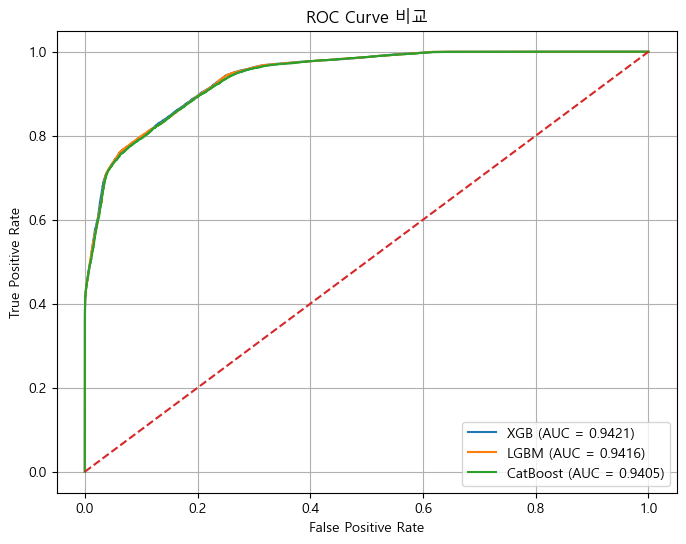

In [83]:
# ROC Curve 시각화로 모델 분류 성능 비교
plt.figure(figsize=(8, 6))

plt.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC = {auc_xgb:.4f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LGBM (AUC = {auc_lgbm:.4f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve 비교')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

# 최종 선택 모델(LightGBM)의 Feature Importance 분석

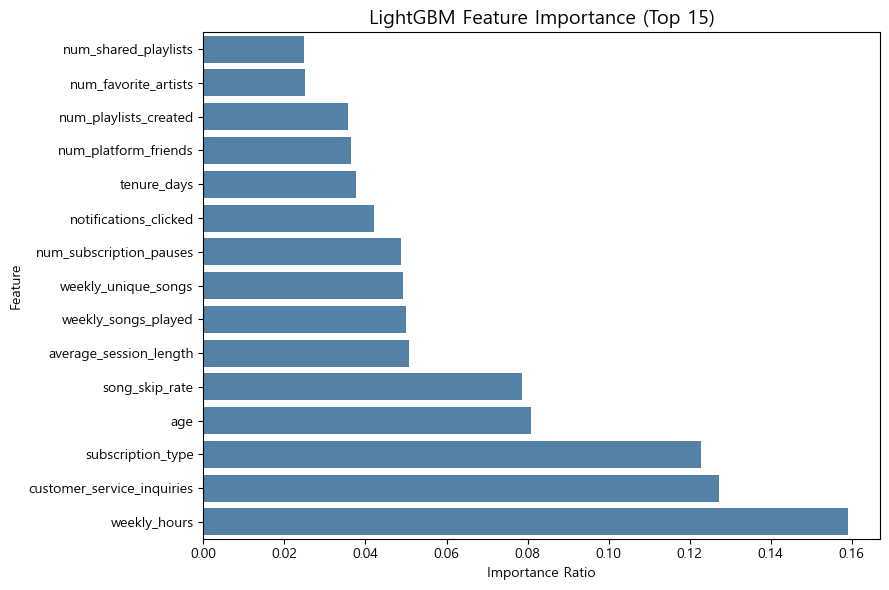

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LightGBM 변수 중요도 데이터프레임 생성
final_model = final_lgbm
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": final_model.feature_importances_
})

# 중요도 비율 계산
importance_df["importance_ratio"] = (
    importance_df["importance"] / importance_df["importance"].sum()
)

# 상위 15개 변수 선택
top_n = 15
plot_df = (
    importance_df
    .sort_values("importance_ratio", ascending=False)
    .head(top_n)
    .sort_values("importance_ratio")
)

# ightGBM 주요 변수 중요도 시각화
plt.figure(figsize=(9,6))

sns.barplot(
    data=plot_df,
    x="importance_ratio",
    y="feature",
    color="steelblue"
)

plt.title("LightGBM Feature Importance (Top 15)", fontsize=14)
plt.xlabel("Importance Ratio")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()